# 05b — Relevance effect, POST > PRE viewing GLM

This notebook tests whether the **goal-relevance effect** changes from PRE to POST viewing.

Main contrast:

$$
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})
-
(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})
$$

Interpretation:

> Images that were goal-relevant during Island encoding show a stronger POST-vs-PRE increase than goal-irrelevant images.

This is the direct **Relevant > Irrelevant, POST > PRE** model.

For now, the notebook produces clean whole-brain exploratory peak tables only.  
SVC and final figure cells can be added later once the candidate peaks are selected and matched to papers.


In [4]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import gc
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display
from nilearn.image import load_img, new_img_like
from nilearn import plotting
from nilearn.plotting import plot_design_matrix
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 200)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.contrasts import (
    contrast_specs_to_table,
)
from island_glm.first_level import fit_two_run_first_level
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table

# ------------------------------------------------------------
# Analysis identity
# ------------------------------------------------------------

ANALYSIS_NAME = "pre_post_relevance_old_new_viewing_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------
# First full run:
#   RUN_FIRST_LEVEL=True, OVERWRITE_FIRST_LEVEL=True
#
# After first-level maps are successfully saved:
#   RUN_FIRST_LEVEL=False, OVERWRITE_FIRST_LEVEL=False
#   RUN_SECOND_LEVEL=True only when you changed contrast definitions.
# ------------------------------------------------------------

RUN_FIRST_LEVEL = False
OVERWRITE_FIRST_LEVEL = False

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

# Display / table settings
DISPLAY_THRESHOLD_Z = 2.33
STRICT_THRESHOLD_Z = 3.00
CLUSTER_THRESHOLD_VOXELS = 10
VMAX = 5.0

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])


Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm


## Load common inputs

The analysis uses the same final subject set and mean T1w background as the previous notebooks.


In [5]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)

# Main sample includes high-motion subjects; sensitivity list excludes them.
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"

mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Event model

For each subject, the two-run first-level GLM contains one PRE viewing run and one POST viewing run.

Task regressors:

\[
\beta_{\mathrm{pre,oldRel}},\quad
\beta_{\mathrm{pre,oldIrrel}},\quad
\beta_{\mathrm{pre,new}},
\quad
\beta_{\mathrm{post,oldRel}},\quad
\beta_{\mathrm{post,oldIrrel}},\quad
\beta_{\mathrm{post,new}}.
\]

`pre_new` and `post_new` are included as control regressors but are not part of the main relevance interaction.


In [6]:
# ============================================================
# 3. Local event functions for PRE/POST relevance model
# ============================================================

def normalise_relevance_code(value):
    """Return 'relevant', 'irrelevant', or None from common relevance encodings."""
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    if value in {"r", "re", "rel", "relevant", "oldrel"}:
        return "relevant"
    if value in {"nr", "irrel", "irrelevant", "oldirrel", "not_relevant", "nonrelevant", "non-relevant"}:
        return "irrelevant"
    return None


def label_pre_post_relevance_trial(row, phase):
    """Return phase-specific trial type for relevant/irrelevant old images and new controls."""
    old_new = str(row.get("old_new", "")).strip().lower()
    relevance = normalise_relevance_code(row.get("relevance"))

    if old_new == "new":
        return f"{phase}_new"
    if old_new == "old" and relevance == "relevant":
        return f"{phase}_oldRel"
    if old_new == "old" and relevance == "irrelevant":
        return f"{phase}_oldIrrel"
    return f"{phase}_other"


def make_pre_post_relevance_events(viewing_item_labels, subject, phase):
    """Build BIDS-compatible PRE/POST relevance events for one subject and phase."""
    required_cols = ["subject", "phase", "onset", "duration", "old_new", "relevance"]
    missing = [col for col in required_cols if col not in viewing_item_labels.columns]
    if missing:
        raise ValueError(f"Missing columns in viewing_item_labels: {missing}")

    events = viewing_item_labels.query("subject == @subject and phase == @phase").copy()
    if events.empty:
        raise ValueError(f"No events found for {subject}, phase={phase}")

    events["trial_type"] = events.apply(lambda row: label_pre_post_relevance_trial(row, phase), axis=1)
    events["modulation"] = 1.0

    out = events[["onset", "duration", "trial_type", "modulation"]].copy()
    out = out.sort_values("onset").reset_index(drop=True)
    return out


def save_pre_post_relevance_subject_events(viewing_item_labels, subject, events_dir):
    """Save PRE and POST relevance event files for one subject."""
    events_dir.mkdir(parents=True, exist_ok=True)
    paths_out = {}

    for phase in ["pre", "post"]:
        events = make_pre_post_relevance_events(viewing_item_labels, subject, phase=phase)
        path = events_dir / f"{subject}_{phase}_task-viewing_pre_post_relevance_events.tsv"
        events.to_csv(path, sep="\t", index=False)
        paths_out[phase] = path

    return paths_out


def build_pre_post_relevance_event_qc(viewing_item_labels, subjects, events_dir=None):
    """Create event-count QC for the PRE/POST relevance model."""
    rows = []
    all_events = []

    for subject in subjects:
        for phase in ["pre", "post"]:
            events = make_pre_post_relevance_events(viewing_item_labels, subject, phase=phase)
            counts = events["trial_type"].value_counts().to_dict()

            path = (
                events_dir / f"{subject}_{phase}_task-viewing_pre_post_relevance_events.tsv"
                if events_dir is not None
                else ""
            )

            rows.append({
                "subject": subject,
                "phase": phase,
                "n_events": len(events),
                f"n_{phase}_oldRel": counts.get(f"{phase}_oldRel", 0),
                f"n_{phase}_oldIrrel": counts.get(f"{phase}_oldIrrel", 0),
                f"n_{phase}_new": counts.get(f"{phase}_new", 0),
                f"n_{phase}_other": counts.get(f"{phase}_other", 0),
                "events_path": str(path),
            })

            tmp = events.copy()
            tmp["subject"] = subject
            tmp["phase"] = phase
            all_events.append(tmp)

    return pd.DataFrame(rows), pd.concat(all_events, ignore_index=True)


## Contrasts

The primary contrast is the POST > PRE change in the relevance effect:

$$
C_{\mathrm{rel>irrel,\ POST>PRE}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})
-
(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})
$$

The reverse control is also included.


In [7]:
# ============================================================
# 4. Define PRE/POST relevance contrasts
# ============================================================

def make_pre_post_relevance_contrasts():
    """Contrasts for PRE/POST relevance old-image viewing GLM."""
    return {
        "rel_gt_irrel_post_gt_pre": {
            "priority": "primary_relevance_post_pre_interaction",
            "formula": (
                r"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})"
                r"-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$"
            ),
            "interpretation": "Relevant > irrelevant old-image response is stronger at POST than PRE.",
            "weights": {
                "post_oldRel": 1.0,
                "post_oldIrrel": -1.0,
                "pre_oldRel": -1.0,
                "pre_oldIrrel": 1.0,
            },
        },
        "irrel_gt_rel_post_gt_pre": {
            "priority": "reverse_relevance_post_pre_interaction",
            "formula": (
                r"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})"
                r"-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$"
            ),
            "interpretation": "Irrelevant > relevant old-image response is stronger at POST than PRE.",
            "weights": {
                "post_oldIrrel": 1.0,
                "post_oldRel": -1.0,
                "pre_oldIrrel": -1.0,
                "pre_oldRel": 1.0,
            },
        },
        "pre_rel_gt_irrel": {
            "priority": "descriptive_pre_relevance_effect",
            "formula": r"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}}$$",
            "interpretation": "PRE relevant old images > PRE irrelevant old images.",
            "weights": {
                "pre_oldRel": 1.0,
                "pre_oldIrrel": -1.0,
            },
        },
        "post_rel_gt_irrel": {
            "priority": "descriptive_post_relevance_effect",
            "formula": r"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}}$$",
            "interpretation": "POST relevant old images > POST irrelevant old images.",
            "weights": {
                "post_oldRel": 1.0,
                "post_oldIrrel": -1.0,
            },
        },
        "rel_old_gt_new_post_gt_pre": {
            "priority": "descriptive_relevant_old_new_post_pre",
            "formula": (
                r"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,new}})"
                r"-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,new}})$$"
            ),
            "interpretation": "Relevant old > new effect is stronger at POST than PRE.",
            "weights": {
                "post_oldRel": 1.0,
                "post_new": -1.0,
                "pre_oldRel": -1.0,
                "pre_new": 1.0,
            },
        },
        "irrel_old_gt_new_post_gt_pre": {
            "priority": "descriptive_irrelevant_old_new_post_pre",
            "formula": (
                r"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})"
                r"-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$"
            ),
            "interpretation": "Irrelevant old > new effect is stronger at POST than PRE.",
            "weights": {
                "post_oldIrrel": 1.0,
                "post_new": -1.0,
                "pre_oldIrrel": -1.0,
                "pre_new": 1.0,
            },
        },
    }


contrast_specs = make_pre_post_relevance_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)


,contrast,priority,formula,interpretation,post_oldRel,post_oldIrrel,pre_oldRel,pre_oldIrrel,post_new,pre_new
0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",Relevant > irrelevant old-image response is stronger at POST than PRE.,1.0,-1.0,-1.0,1.0,0.0,0.0
1,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",Irrelevant > relevant old-image response is stronger at POST than PRE.,-1.0,1.0,1.0,-1.0,0.0,0.0
2,pre_rel_gt_irrel,descriptive_pre_relevance_effect,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}}$$",PRE relevant old images > PRE irrelevant old images.,0.0,0.0,1.0,-1.0,0.0,0.0
3,post_rel_gt_irrel,descriptive_post_relevance_effect,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}}$$",POST relevant old images > POST irrelevant old images.,1.0,-1.0,0.0,0.0,0.0,0.0
4,rel_old_gt_new_post_gt_pre,descriptive_relevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,new}})$$",Relevant old > new effect is stronger at POST than PRE.,1.0,0.0,-1.0,0.0,-1.0,1.0
5,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",Irrelevant old > new effect is stronger at POST than PRE.,0.0,1.0,0.0,-1.0,-1.0,1.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_contrast_definitions.csv


In [8]:
# ============================================================
# 5. Create PRE/POST relevance event files and event-count QC
# ============================================================

for subject in subjects:
    save_pre_post_relevance_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
    )

event_qc, all_events_long = build_pre_post_relevance_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="\t", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("\nEvent counts by phase and trial type:")
display(
    all_events_long
    .groupby(["phase", "trial_type"])
    .size()
    .reset_index(name="n")
)

display(event_qc.head())

# Expected counts per subject and phase.
# PRE and POST should both contain the same old-image relevance split.
for phase in ["pre", "post"]:
    phase_qc = event_qc.query("phase == @phase").copy()
    assert (phase_qc[f"n_{phase}_oldRel"] == 144).all(), f"Expected 144 {phase}_oldRel trials per subject."
    assert (phase_qc[f"n_{phase}_oldIrrel"] == 144).all(), f"Expected 144 {phase}_oldIrrel trials per subject."
    assert (phase_qc[f"n_{phase}_new"] == 96).all(), f"Expected 96 {phase}_new trials per subject."
    assert (phase_qc[f"n_{phase}_other"] == 0).all(), f"Unexpected {phase}_other events found."

print("Event QC passed.")


Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/all_subjects_pre_post_relevance_old_new_viewing_glm_events_long.tsv

Event counts by phase and trial type:


,phase,trial_type,n
0,post,post_new,2592
1,post,post_oldIrrel,3888
2,post,post_oldRel,3888
3,pre,pre_new,2592
4,pre,pre_oldIrrel,3888
5,pre,pre_oldRel,3888


,subject,phase,n_events,n_pre_oldRel,n_pre_oldIrrel,n_pre_new,n_pre_other,events_path,n_post_oldRel,n_post_oldIrrel,n_post_new,n_post_other
0,sub-P10,pre,384,144.0,144.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/sub-P10_pre_task-viewing_pre_post_relevance_events.tsv,NaN,NaN,NaN,NaN
1,sub-P10,post,384,NaN,NaN,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/sub-P10_post_task-viewing_pre_post_relevance_events.tsv,144.0,144.0,96.0,0.0
2,sub-P12,pre,384,144.0,144.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/sub-P12_pre_task-viewing_pre_post_relevance_events.tsv,NaN,NaN,NaN,NaN
3,sub-P12,post,384,NaN,NaN,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/sub-P12_post_task-viewing_pre_post_relevance_events.tsv,144.0,144.0,96.0,0.0
4,sub-P13,pre,384,144.0,144.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new_viewing_glm/sub-P13_pre_task-viewing_pre_post_relevance_events.tsv,NaN,NaN,NaN,NaN


Event QC passed.


In [9]:
# ============================================================
# 6. Single-subject design and contrast preview
# ============================================================

preview_events_by_phase = {
    "pre": make_pre_post_relevance_events(viewing_item_labels, TEST_SUBJECT, "pre"),
    "post": make_pre_post_relevance_events(viewing_item_labels, TEST_SUBJECT, "post"),
}

preview_subject_qc, preview_contrast_qc = fit_two_run_first_level(
    subject=TEST_SUBJECT,
    paths=paths,
    events_by_phase=preview_events_by_phase,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=False,
)

preview_subject_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
)

preview_contrast_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"
)

preview_subject_qc.to_csv(preview_subject_qc_path, index=False)
preview_contrast_qc.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(preview_subject_qc)

print("Contrast-vector preview:")
display(preview_contrast_qc)

assert not preview_contrast_qc.groupby("contrast")["is_null_vector"].all().any()

print("Design and contrast-vector preview passed.")


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 1 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 1 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 0 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 0 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")


Subject QC preview:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P15,1.3,1986,1995,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,65,True,True,False,69,69,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine17;co...,post_new;post_oldIrrel;post_oldRel;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine17...


Contrast-vector preview:


,subject,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,sub-P15,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,1,69,2,pre_oldIrrel;pre_oldRel,1.0;-1.0,post_oldRel;post_oldIrrel,False
1,sub-P15,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,2,69,2,post_oldIrrel;post_oldRel,-1.0;1.0,pre_oldRel;pre_oldIrrel,False
2,sub-P15,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,1,69,2,pre_oldIrrel;pre_oldRel,-1.0;1.0,post_oldIrrel;post_oldRel,False
3,sub-P15,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,2,69,2,post_oldIrrel;post_oldRel,1.0;-1.0,pre_oldIrrel;pre_oldRel,False
4,sub-P15,pre_rel_gt_irrel,descriptive_pre_relevance_effect,1,69,2,pre_oldIrrel;pre_oldRel,-1.0;1.0,,False
5,sub-P15,pre_rel_gt_irrel,descriptive_pre_relevance_effect,2,69,0,,,pre_oldRel;pre_oldIrrel,True
6,sub-P15,post_rel_gt_irrel,descriptive_post_relevance_effect,1,69,0,,,post_oldRel;post_oldIrrel,True
7,sub-P15,post_rel_gt_irrel,descriptive_post_relevance_effect,2,69,2,post_oldIrrel;post_oldRel,-1.0;1.0,,False
8,sub-P15,rel_old_gt_new_post_gt_pre,descriptive_relevant_old_new_post_pre,1,69,2,pre_new;pre_oldRel,1.0;-1.0,post_oldRel;post_new,False
9,sub-P15,rel_old_gt_new_post_gt_pre,descriptive_relevant_old_new_post_pre,2,69,2,post_new;post_oldRel,-1.0;1.0,pre_oldRel;pre_new,False


Design and contrast-vector preview passed.


In [10]:
# ============================================================
# 7. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_map_rows = []
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True

        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
            z_exists = z_path.exists()
            effect_exists = effect_path.exists()

            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_map_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
            })

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "subject_complete": subject_all_maps_exist,
            "n_contrasts_expected": len(contrast_specs),
            "n_z_maps_found": sum(
                first_level_map_path(dirs, subject, c, smoothing_label, "z").exists()
                for c in contrast_specs.keys()
            ),
            "n_effect_maps_found": sum(
                first_level_map_path(dirs, subject, c, smoothing_label, "effect").exists()
                for c in contrast_specs.keys()
            ),
            "recovered_from_saved_maps": True,
        })

    map_qc_recovered = pd.DataFrame(recovered_map_rows)
    subject_qc_recovered = pd.DataFrame(recovered_qc_rows)
    contrast_qc_recovered = pd.DataFrame(recovered_contrast_rows)

    return subject_qc_recovered, contrast_qc_recovered, map_qc_recovered


if RUN_FIRST_LEVEL:
    first_qc_rows = []
    contrast_qc_rows = []
    failed_rows = []

    for idx, subject in enumerate(subjects, start=1):
        print("=" * 90)
        print(f"[{idx}/{len(subjects)}] First-level GLM: {subject}")

        if (
            subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
            and not OVERWRITE_FIRST_LEVEL
        ):
            print("All maps already exist and OVERWRITE_FIRST_LEVEL=False. Skipping.")
            continue

        try:
            events_by_phase = {
                "pre": make_pre_post_relevance_events(viewing_item_labels, subject, "pre"),
                "post": make_pre_post_relevance_events(viewing_item_labels, subject, "post"),
            }

            subject_qc, contrast_qc = fit_two_run_first_level(
                subject=subject,
                paths=paths,
                events_by_phase=events_by_phase,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )

            first_qc_rows.append(subject_qc)
            contrast_qc_rows.append(contrast_qc)

            # Save after each subject to protect against kernel interruptions.
            pd.concat(first_qc_rows, ignore_index=True).to_csv(first_level_qc_path, index=False)
            pd.concat(contrast_qc_rows, ignore_index=True).to_csv(first_level_contrast_qc_path, index=False)

            print("Saved subject maps and updated QC.")

        except Exception as exc:
            print(f"FAILED: {subject}")
            print(exc)
            failed_rows.append({
                "subject": subject,
                "error": repr(exc),
            })
            pd.DataFrame(failed_rows).to_csv(failed_subjects_path, index=False)

        gc.collect()

    if first_qc_rows:
        first_level_qc = pd.concat(first_qc_rows, ignore_index=True)
        first_level_contrast_qc = pd.concat(contrast_qc_rows, ignore_index=True)
    else:
        print("No new first-level models were run. Recovering QC from saved maps.")
        first_level_qc, first_level_contrast_qc, recovered_map_qc = recover_first_level_qc_from_saved_maps(
            subjects, contrast_specs, dirs, SMOOTHING_LABEL
        )

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)

else:
    print("RUN_FIRST_LEVEL=False. Recovering QC from saved first-level maps.")
    first_level_qc, first_level_contrast_qc, recovered_map_qc = recover_first_level_qc_from_saved_maps(
        subjects, contrast_specs, dirs, SMOOTHING_LABEL
    )
    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)

display(first_level_qc.head())
display(first_level_contrast_qc.head())

print("Saved first-level QC:", first_level_qc_path)
print("Saved contrast QC:", first_level_contrast_qc_path)

if failed_subjects_path.exists():
    failed_subjects = pd.read_csv(failed_subjects_path)
    if len(failed_subjects) > 0:
        print("Failed subjects:")
        display(failed_subjects)


RUN_FIRST_LEVEL=False. Recovering QC from saved first-level maps.


,subject,subject_complete,n_contrasts_expected,n_z_maps_found,n_effect_maps_found,recovered_from_saved_maps
0,sub-P10,True,6,6,6,True
1,sub-P12,True,6,6,6,True
2,sub-P13,True,6,6,6,True
3,sub-P14,True,6,6,6,True
4,sub-P15,True,6,6,6,True


,subject,contrast,z_map_path,effect_map_path,z_map_exists,effect_map_exists,recovered_from_saved_maps
0,sub-P10,rel_gt_irrel_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_rel_gt_irrel_post_gt_pre_smoothed5m...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_rel_gt_irrel_post_gt_pre_smoothed5m...,True,True,True
1,sub-P10,irrel_gt_rel_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_irrel_gt_rel_post_gt_pre_smoothed5m...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_irrel_gt_rel_post_gt_pre_smoothed5m...,True,True,True
2,sub-P10,pre_rel_gt_irrel,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_pre_rel_gt_irrel_smoothed5mm_zmap.n...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_pre_rel_gt_irrel_smoothed5mm_effect...,True,True,True
3,sub-P10,post_rel_gt_irrel,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_post_rel_gt_irrel_smoothed5mm_zmap....,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_post_rel_gt_irrel_smoothed5mm_effec...,True,True,True
4,sub-P10,rel_old_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_rel_old_gt_new_post_gt_pre_smoothed...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_rel_old_gt_new_post_gt_pre_smoothed...,True,True,True


Saved first-level QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_first_level_qc_smoothed5mm.csv
Saved contrast QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_first_level_contrast_qc_smoothed5mm.csv


In [11]:
# ============================================================
# 8. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()

print("First-level map verification passed.")


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,27,27,27
1,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,27,27,27
2,pre_rel_gt_irrel,descriptive_pre_relevance_effect,27,27,27
3,post_rel_gt_irrel,descriptive_post_relevance_effect,27,27,27
4,rel_old_gt_new_post_gt_pre,descriptive_relevant_old_new_post_pre,27,27,27
5,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_first_level_map_qc_smoothed5mm.csv
First-level map verification passed.


In [12]:
# ============================================================
# 9. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_gt_irrel_post_gt_pre_smooth...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_gt_irrel_post_gt_pre_smooth...,True,True
1,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_irrel_gt_rel_post_gt_pre_smooth...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_irrel_gt_rel_post_gt_pre_smooth...,True,True
2,pre_rel_gt_irrel,descriptive_pre_relevance_effect,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_rel_gt_irrel_smoothed5mm_zm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_rel_gt_irrel_smoothed5mm_ef...,True,True
3,post_rel_gt_irrel,descriptive_post_relevance_effect,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_post_rel_gt_irrel_smoothed5mm_z...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_post_rel_gt_irrel_smoothed5mm_e...,True,True
4,rel_old_gt_new_post_gt_pre,descriptive_relevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,new}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_old_gt_new_post_gt_pre_smoo...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_old_gt_new_post_gt_pre_smoo...,True,True
5,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_irrel_old_gt_new_post_gt_pre_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_irrel_old_gt_new_post_gt_pre_sm...,True,True


Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_second_level_maps_smoothed5mm.csv


In [13]:
# ============================================================
# 10. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(DISPLAY_THRESHOLD_Z, STRICT_THRESHOLD_Z),
    cluster_threshold_voxels=CLUSTER_THRESHOLD_VOXELS,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.567429542541504. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.567429542541504. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.567429542541504. But, you have given threshold=4.943085175231748.
  t

Threshold summary:


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
7,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_gt_rel_post_g...
5,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_gt_rel_post_g...
6,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_gt_rel_post_g...
4,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,oldRel}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,oldRel}})$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,58,3.931434,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_gt_rel_post_g...
23,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_old_gt_new_po...
21,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_old_gt_new_po...
22,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_old_gt_new_po...
20,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}})$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,76,4.265341,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_irrel_old_gt_new_po...
15,post_rel_gt_irrel,descriptive_post_relevance_effect,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre

Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
2,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,z_gt_2.33,2.33,10,9,3.931434,515.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_irrel_gt_rel_post_...
3,irrel_gt_rel_post_gt_pre,reverse_relevance_post_pre_interaction,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_irrel_gt_rel_post_...
10,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,z_gt_2.33,2.33,10,15,4.265341,687.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_irrel_old_gt_new_p...
11,irrel_old_gt_new_post_gt_pre,descriptive_irrelevant_old_new_post_pre,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_irrel_old_gt_new_p...
6,post_rel_gt_irrel,descriptive_post_relevance_effect,z_gt_2.33,2.33,10,45,4.301033,4843.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_post_rel_gt_irrel_...
7,post_rel_gt_irrel,descriptive_post_relevance_effect,z_gt_3.00,3.00,10,4,4.301033,343.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_post_rel_gt_irrel_...
4,pre_rel_gt_irrel,descriptive_pre_relevance_effect,z_gt_2.33,2.33,10,12,4.013994,593.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pre_rel_gt_irrel_z...
5,pre_rel_gt_irrel,descriptive_pre_relevance_effect,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pre_rel_gt_irrel_z...
0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,z_gt_2.33,2.33,10,71,4.567430,7078.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_rel_gt_irrel_post_...
1,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,z_gt_3.00,3.00,10,12,4.567430,2718.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_rel_gt_irrel_post_...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_cluster_details_smoothed5mm.csv


In [14]:
# ============================================================
# 11. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(60))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,49.0,45.5,2.0,4.567430,7078.0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
1,1a,39.0,33.0,-8.0,3.889692,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
2,1b,44.0,40.5,-5.5,3.853935,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
3,1c,39.0,45.5,7.0,3.834531,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
4,2,1.5,-44.5,44.5,4.211428,2406.0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Precuneous Cortex,31,Right Cerebral Cortex,13
5,2a,6.5,-34.5,44.5,2.948805,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,"Cingulate Gyrus, posterior division",30,Right Cerebral Cortex,13
6,2b,1.5,-42.0,62.0,2.839913,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Precuneous Cortex,31,Right Cerebral Cortex,13
7,2c,4.0,-24.5,47.0,2.824101,NaN,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,"Cingulate Gyrus, posterior division",30,Right Cerebral Cortex,13
8,3,21.5,-32.0,-28.0,4.138272,156.0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Background,0,Background,0
9,4,-6.0,-19.5,29.5,4.061832,1531.0,rel_gt_irrel_post_gt_pre,primary_relevance_post_pre_interaction,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,oldIrrel}})-(\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,oldIrrel}})$$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_viewing_glm_cluster_details_labeled_smoothed5mm.csv


## Candidate peak output

This is the main handoff cell for selecting peaks for paper matching and later SVC.

It saves:

- a full labeled peak table,
- a compact report-ready peak table,
- a PNG table with wrapped text,
- whole-brain voxelwise FDR information for the primary contrast.

At this stage, these peaks are **exploratory whole-brain peaks**.  
No SVC inference is performed yet.


In [15]:
# ============================================================
# 12. Candidate peaks for Relevant > Irrelevant, POST > PRE
# ============================================================

PRIMARY_CONTRAST = "rel_gt_irrel_post_gt_pre"
REVERSE_CONTRAST = "irrel_gt_rel_post_gt_pre"

PRIMARY_LABEL = "Relevant > irrelevant, POST > PRE"
REVERSE_LABEL = "Irrelevant > relevant, POST > PRE"

candidate_peak_dir = dirs["tables"] / "candidate_peaks_for_literature_matching"
candidate_peak_fig_dir = dirs["figures"] / "candidate_peaks_for_literature_matching"

candidate_peak_dir.mkdir(parents=True, exist_ok=True)
candidate_peak_fig_dir.mkdir(parents=True, exist_ok=True)


def atlas_label_from_row(row):
    cortical = row.get("harvard_oxford_cortical_label", "")
    subcortical = row.get("harvard_oxford_subcortical_label", "")

    if pd.notna(cortical) and cortical not in ["", "Background"]:
        return cortical
    if pd.notna(subcortical) and subcortical not in ["", "Background"]:
        return subcortical
    return "Unlabelled / outside atlas"


def fmt_coord_from_row(row):
    return f"({float(row['X']):.0f}, {float(row['Y']):.0f}, {float(row['Z']):.0f})"


def get_candidate_peaks(contrast_name, contrast_label, threshold_label="z_gt_2.33", top_n=25):
    subset = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == @threshold_label"
    ).copy()

    if len(subset) == 0:
        return pd.DataFrame()

    subset["Atlas label"] = subset.apply(atlas_label_from_row, axis=1)
    subset["Peak"] = subset.apply(fmt_coord_from_row, axis=1)
    subset["Peak z"] = subset["Peak Stat"].astype(float)

    subset = subset.sort_values("Peak z", ascending=False).head(top_n)

    out = subset[
        [
            "contrast",
            "threshold_label",
            "Cluster ID",
            "Peak",
            "Peak z",
            "Cluster Size (mm3)",
            "Atlas label",
            "X", "Y", "Z",
            "harvard_oxford_cortical_label",
            "harvard_oxford_subcortical_label",
        ]
    ].copy()

    out.insert(0, "Contrast label", contrast_label)
    out["Suggested figure title"] = out.apply(
        lambda row: f"{contrast_label}, peak z = {row['Peak z']:.2f}\n{row['Atlas label']}",
        axis=1,
    )

    return out


primary_candidate_peaks = get_candidate_peaks(
    PRIMARY_CONTRAST,
    PRIMARY_LABEL,
    threshold_label=f"z_gt_{DISPLAY_THRESHOLD_Z:.2f}",
    top_n=25,
)

reverse_candidate_peaks = get_candidate_peaks(
    REVERSE_CONTRAST,
    REVERSE_LABEL,
    threshold_label=f"z_gt_{DISPLAY_THRESHOLD_Z:.2f}",
    top_n=25,
)

candidate_peaks_all = pd.concat(
    [primary_candidate_peaks, reverse_candidate_peaks],
    ignore_index=True,
)

primary_csv = candidate_peak_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_candidate_peaks_zgt{DISPLAY_THRESHOLD_Z:.2f}.csv"
reverse_csv = candidate_peak_dir / f"{ANALYSIS_NAME}_{REVERSE_CONTRAST}_candidate_peaks_zgt{DISPLAY_THRESHOLD_Z:.2f}.csv"
all_csv = candidate_peak_dir / f"{ANALYSIS_NAME}_primary_and_reverse_candidate_peaks_zgt{DISPLAY_THRESHOLD_Z:.2f}.csv"

primary_candidate_peaks.to_csv(primary_csv, index=False)
reverse_candidate_peaks.to_csv(reverse_csv, index=False)
candidate_peaks_all.to_csv(all_csv, index=False)

print("Primary candidate peaks:")
display(primary_candidate_peaks)

print("\nReverse candidate peaks:")
display(reverse_candidate_peaks)

print("\nSaved:")
print(primary_csv)
print(reverse_csv)
print(all_csv)


# ------------------------------------------------------------
# Whole-brain voxelwise FDR for primary contrast
# ------------------------------------------------------------

z_map_path = Path(
    second_level_table.set_index("contrast").loc[PRIMARY_CONTRAST, "z_map_path"]
)
z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

brain_mask = np.isfinite(z_data) & (np.abs(z_data) > 0)
z_values = z_data[brain_mask]
p_values_wb = norm.sf(z_values)  # one-sided positive Relevant > Irrelevant, POST > PRE

_, q_values_wb, _, _ = multipletests(
    p_values_wb,
    alpha=0.05,
    method="fdr_bh",
)

q_map_data = np.full(z_data.shape, np.nan)
q_map_data[brain_mask] = q_values_wb

wb_min_q = float(np.nanmin(q_map_data))
wb_n_q05 = int(np.sum(q_map_data < 0.05))
wb_n_q10 = int(np.sum(q_map_data < 0.10))

q_map_img = new_img_like(z_img, q_map_data)
q_map_path = candidate_peak_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_wholebrain_voxelwise_qFDR_map.nii.gz"
q_map_img.to_filename(str(q_map_path))

print("\nWhole-brain voxelwise FDR for primary contrast:")
print(f"Minimum qFDR: {wb_min_q:.3f}")
print(f"n voxels qFDR < .05: {wb_n_q05}")
print(f"n voxels qFDR < .10: {wb_n_q10}")
print("Saved qFDR map:", q_map_path)


# Add whole-brain q at candidate peaks.
if len(primary_candidate_peaks) > 0:
    q_at_peaks = []
    for _, row in primary_candidate_peaks.iterrows():
        coord = np.array([float(row["X"]), float(row["Y"]), float(row["Z"]), 1.0])
        voxel = np.round(np.linalg.inv(z_img.affine).dot(coord)[:3]).astype(int)

        if (
            0 <= voxel[0] < q_map_data.shape[0]
            and 0 <= voxel[1] < q_map_data.shape[1]
            and 0 <= voxel[2] < q_map_data.shape[2]
        ):
            q_at_peaks.append(float(q_map_data[tuple(voxel)]))
        else:
            q_at_peaks.append(np.nan)

    primary_candidate_peaks["Whole-brain qFDR at peak"] = q_at_peaks

    primary_with_q_csv = candidate_peak_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_candidate_peaks_with_wholebrain_qFDR.csv"
    primary_candidate_peaks.to_csv(primary_with_q_csv, index=False)

    print("\nPrimary candidate peaks with whole-brain qFDR:")
    display(primary_candidate_peaks)
    print("Saved:", primary_with_q_csv)


Primary candidate peaks:


,Contrast label,contrast,threshold_label,Cluster ID,Peak,Peak z,Cluster Size (mm3),Atlas label,X,Y,Z,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,Suggested figure title
0,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1,"(49, 46, 2)",4.567430,7078.0,Frontal Pole,49.0,45.5,2.0,Frontal Pole,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.57\nFrontal Pole"
4,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,2,"(2, -44, 44)",4.211428,2406.0,Precuneous Cortex,1.5,-44.5,44.5,Precuneous Cortex,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.21\nPrecuneous Cortex"
8,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,3,"(22, -32, -28)",4.138272,156.0,Unlabelled / outside atlas,21.5,-32.0,-28.0,Background,Background,"Relevant > irrelevant, POST > PRE, peak z = 4.14\nUnlabelled / outside atlas"
9,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,4,"(-6, -20, 30)",4.061832,1531.0,Left Cerebral White Matter,-6.0,-19.5,29.5,Background,Left Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nLeft Cerebral White Matter"
12,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,5,"(-28, 0, 62)",4.057786,1484.0,Superior Frontal Gyrus,-28.5,0.5,62.0,Superior Frontal Gyrus,Left Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nSuperior Frontal Gyrus"
16,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,6,"(-46, 56, 2)",4.048796,984.0,Unlabelled / outside atlas,-46.0,55.5,2.0,Background,Background,"Relevant > irrelevant, POST > PRE, peak z = 4.05\nUnlabelled / outside atlas"
19,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,7,"(-41, -7, 32)",4.031641,343.0,Left Cerebral White Matter,-41.0,-7.0,32.0,Background,Left Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 4.03\nLeft Cerebral White Matter"
1,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1a,"(39, 33, -8)",3.889692,NaN,Right Cerebral White Matter,39.0,33.0,-8.0,Background,Right Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 3.89\nRight Cerebral White Matter"
20,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,8,"(44, -54, 44)",3.857484,500.0,Angular Gyrus,44.0,-54.5,44.5,Angular Gyrus,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 3.86\nAngular Gyrus"
2,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1b,"(44, 40, -6)",3.853935,NaN,Frontal Pole,44.0,40.5,-5.5,Frontal Pole,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 3.85\nFrontal Pole"



Reverse candidate peaks:


,Contrast label,contrast,threshold_label,Cluster ID,Peak,Peak z,Cluster Size (mm3),Atlas label,X,Y,Z,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,Suggested figure title
150,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,1,"(6, -47, -38)",3.931434,437.0,Unlabelled / outside atlas,6.5,-47.0,-38.0,Background,Background,"Irrelevant > relevant, POST > PRE, peak z = 3.93\nUnlabelled / outside atlas"
152,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,2,"(-26, -17, 52)",3.890667,515.0,Left Cerebral White Matter,-26.0,-17.0,52.0,Background,Left Cerebral White Matter,"Irrelevant > relevant, POST > PRE, peak z = 3.89\nLeft Cerebral White Matter"
153,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,3,"(14, 20, 40)",3.673783,218.0,Right Cerebral White Matter,14.0,20.5,39.5,Background,Right Cerebral White Matter,"Irrelevant > relevant, POST > PRE, peak z = 3.67\nRight Cerebral White Matter"
154,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,4,"(-21, -32, 54)",3.425516,250.0,Left Cerebral White Matter,-21.0,-32.0,54.5,Background,Left Cerebral White Matter,"Irrelevant > relevant, POST > PRE, peak z = 3.43\nLeft Cerebral White Matter"
151,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,1a,"(22, -40, -38)",3.374335,NaN,Unlabelled / outside atlas,21.5,-39.5,-38.0,Background,Background,"Irrelevant > relevant, POST > PRE, peak z = 3.37\nUnlabelled / outside atlas"
155,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,5,"(46, -22, 60)",3.357945,234.0,Postcentral Gyrus,46.5,-22.0,59.5,Postcentral Gyrus,Right Cerebral Cortex,"Irrelevant > relevant, POST > PRE, peak z = 3.36\nPostcentral Gyrus"
156,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,6,"(14, 0, -6)",3.314795,281.0,Right Pallidum,14.0,0.5,-5.5,Background,Right Pallidum,"Irrelevant > relevant, POST > PRE, peak z = 3.31\nRight Pallidum"
157,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,7,"(16, 16, 50)",3.257857,218.0,Right Cerebral White Matter,16.5,15.5,49.5,Background,Right Cerebral White Matter,"Irrelevant > relevant, POST > PRE, peak z = 3.26\nRight Cerebral White Matter"
158,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,8,"(22, 46, 10)",3.123415,156.0,Right Cerebral White Matter,21.5,45.5,9.5,Background,Right Cerebral White Matter,"Irrelevant > relevant, POST > PRE, peak z = 3.12\nRight Cerebral White Matter"
159,"Irrelevant > relevant, POST > PRE",irrel_gt_rel_post_gt_pre,z_gt_2.33,9,"(39, 10, -20)",2.882279,296.0,Temporal Pole,39.0,10.5,-20.5,Temporal Pole,Right Cerebral Cortex,"Irrelevant > relevant, POST > PRE, peak z = 2.88\nTemporal Pole"



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/candidate_peaks_for_literature_matching/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_candidate_peaks_zgt2.33.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/candidate_peaks_for_literature_matching/pre_post_relevance_old_new_viewing_glm_irrel_gt_rel_post_gt_pre_candidate_peaks_zgt2.33.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/candidate_peaks_for_literature_matching/pre_post_relevance_old_new_viewing_glm_primary_and_reverse_candidate_peaks_zgt2.33.csv

Whole-brain voxelwise FDR for primary contrast:
Minimum qFDR: 0.132
n voxels qFDR < .05: 0
n voxels qFDR < .10: 0
Saved qFDR map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/proces

,Contrast label,contrast,threshold_label,Cluster ID,Peak,Peak z,Cluster Size (mm3),Atlas label,X,Y,Z,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,Suggested figure title,Whole-brain qFDR at peak
0,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1,"(49, 46, 2)",4.567430,7078.0,Frontal Pole,49.0,45.5,2.0,Frontal Pole,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.57\nFrontal Pole",0.132468
4,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,2,"(2, -44, 44)",4.211428,2406.0,Precuneous Cortex,1.5,-44.5,44.5,Precuneous Cortex,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.21\nPrecuneous Cortex",0.138054
8,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,3,"(22, -32, -28)",4.138272,156.0,Unlabelled / outside atlas,21.5,-32.0,-28.0,Background,Background,"Relevant > irrelevant, POST > PRE, peak z = 4.14\nUnlabelled / outside atlas",0.138054
9,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,4,"(-6, -20, 30)",4.061832,1531.0,Left Cerebral White Matter,-6.0,-19.5,29.5,Background,Left Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nLeft Cerebral White Matter",0.152159
12,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,5,"(-28, 0, 62)",4.057786,1484.0,Superior Frontal Gyrus,-28.5,0.5,62.0,Superior Frontal Gyrus,Left Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nSuperior Frontal Gyrus",0.152159
16,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,6,"(-46, 56, 2)",4.048796,984.0,Unlabelled / outside atlas,-46.0,55.5,2.0,Background,Background,"Relevant > irrelevant, POST > PRE, peak z = 4.05\nUnlabelled / outside atlas",0.152159
19,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,7,"(-41, -7, 32)",4.031641,343.0,Left Cerebral White Matter,-41.0,-7.0,32.0,Background,Left Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 4.03\nLeft Cerebral White Matter",0.152916
1,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1a,"(39, 33, -8)",3.889692,NaN,Right Cerebral White Matter,39.0,33.0,-8.0,Background,Right Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 3.89\nRight Cerebral White Matter",0.163161
20,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,8,"(44, -54, 44)",3.857484,500.0,Angular Gyrus,44.0,-54.5,44.5,Angular Gyrus,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 3.86\nAngular Gyrus",0.173809
2,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1b,"(44, 40, -6)",3.853935,NaN,Frontal Pole,44.0,40.5,-5.5,Frontal Pole,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 3.85\nFrontal Pole",0.173809


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/candidate_peaks_for_literature_matching/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_candidate_peaks_with_wholebrain_qFDR.csv


In [16]:
# ============================================================
# Relevant > Irrelevant, POST > PRE
# Literature-coordinate matching + exploratory 6 mm SVC scan
#
# Goal:
# 1. Match observed candidate peaks to previously defined literature coordinates.
# 2. Run 6 mm SVCs at all literature coordinates.
# 3. Highlight the most relevant effects for final paper/SVC selection.
#
# This does NOT yet make final figures.
# It gives us a clean table to choose 2–3 final regions.
# ============================================================

import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from nilearn.image import load_img, new_img_like, resample_to_img
from IPython.display import display

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

PRIMARY_CONTRAST = "rel_gt_irrel_post_gt_pre"
PRIMARY_LABEL = "Relevant > irrelevant, POST > PRE"

SVC_RADIUS_MM = 6.0
MATCH_DISTANCE_MM = 12.0

# Output folder
rel_svc_dir = dirs["tables"] / "relevance_post_gt_pre_literature_svc_screen"
rel_svc_dir.mkdir(parents=True, exist_ok=True)

print("Saving SVC screening tables to:", rel_svc_dir)

# ------------------------------------------------------------
# Load primary z-map
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found."

available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()
assert PRIMARY_CONTRAST in available_contrasts, f"{PRIMARY_CONTRAST} not found in second_level_table."

z_map_path = Path(
    second_level_table.set_index("contrast").loc[PRIMARY_CONTRAST, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using contrast:", PRIMARY_CONTRAST)
print("Using z-map:", z_map_path)

# ------------------------------------------------------------
# Load candidate peaks
# ------------------------------------------------------------

candidate_csv = (
    dirs["tables"]
    / "candidate_peaks_for_literature_matching"
    / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_candidate_peaks_zgt2.33.csv"
)

if candidate_csv.exists():
    candidate_peaks = pd.read_csv(candidate_csv)
    print("Loaded candidate peaks:", candidate_csv)
else:
    # Fallback if the variable already exists in notebook
    assert "primary_candidate_peaks" in globals(), (
        "Could not find candidate CSV and primary_candidate_peaks is not defined."
    )
    candidate_peaks = primary_candidate_peaks.copy()
    print("Using primary_candidate_peaks variable from notebook.")

# Ensure coordinate columns exist
for c in ["X", "Y", "Z"]:
    assert c in candidate_peaks.columns, f"Missing coordinate column: {c}"

candidate_peaks = candidate_peaks.copy()
candidate_peaks["Peak coord"] = candidate_peaks.apply(
    lambda r: (float(r["X"]), float(r["Y"]), float(r["Z"])),
    axis=1
)

display(candidate_peaks.head())

# ------------------------------------------------------------
# Literature coordinates already used / relevant to this project
# ------------------------------------------------------------
# We include:
# - Old/New coordinates already checked
# - Relevance-network likely coordinates
# - Hippocampus/amygdala/MTL coordinates from previous notebooks
#
# The idea is intentionally broad now: screen first, then choose final 2–3.
# ------------------------------------------------------------

LITERATURE_COORDS = [
    # --------------------------------------------------------
    # Old/New paper-sourced coordinates
    # --------------------------------------------------------
    {
        "family": "Old/New selected peaks",
        "region": "Brainstem / SN-VTA",
        "center": (6.0, -15.0, -14.0),
        "source": "Yi et al. (2025)",
        "source_type": "SVC coordinate",
        "interpretation": "Reward/contextual unexpectedness, salience, memory encoding/retrieval",
        "priority": "include",
    },
    {
        "family": "Old/New selected peaks",
        "region": "Paracingulate / medial prefrontal cortex",
        "center": (6.0, 32.0, 30.0),
        "source": "Bengtsson et al. (2011)",
        "source_type": "SVC coordinate",
        "interpretation": "Performance monitoring / task relevance",
        "priority": "include",
    },
    {
        "family": "Old/New selected peaks",
        "region": "Right angular gyrus",
        "center": (56.0, -48.0, 34.0),
        "source": "Carbonell et al. (2014)",
        "source_type": "SVC coordinate",
        "interpretation": "Right angular gyrus seed; interpretation from Bonnici/Grob",
        "priority": "include",
    },
    {
        "family": "Old/New selected peaks",
        "region": "Right anterior parahippocampal cortex",
        "center": (20.0, -14.0, -30.0),
        "source": "Irish et al. (2016)",
        "source_type": "SVC coordinate",
        "interpretation": "Right anterior PHC / MTL contextual episodic memory",
        "priority": "include",
    },
    {
        "family": "Old/New selected peaks",
        "region": "Left anterior hippocampus",
        "center": (-15.0, -8.5, -14.5),
        "source": "Montagrin et al. (2024)",
        "source_type": "SVC coordinate",
        "interpretation": "Present vs past/future goals; anterior hippocampus",
        "priority": "include",
    },

    # --------------------------------------------------------
    # Relevance-network candidate regions from your rel>irrel POST-only / current table
    # These are not all final SVC coordinates yet, but useful for matching.
    # --------------------------------------------------------
    {
        "family": "Relevance network",
        "region": "Right frontal pole",
        "center": (49.0, 45.5, 2.0),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "Goal relevance / high-level control / rostrolateral PFC",
        "priority": "candidate",
    },
    {
        "family": "Relevance network",
        "region": "Precuneus / posterior medial cortex",
        "center": (1.5, -44.5, 44.5),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "Episodic retrieval / scene construction / self-referential contextual processing",
        "priority": "candidate",
    },
    {
        "family": "Relevance network",
        "region": "Left superior frontal gyrus",
        "center": (-28.5, 0.5, 62.0),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "Dorsal frontoparietal control / goal relevance",
        "priority": "candidate",
    },
    {
        "family": "Relevance network",
        "region": "Right angular / IPL",
        "center": (44.0, -54.5, 44.5),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "Angular/IPL memory integration and attention to memory",
        "priority": "candidate",
    },
    {
        "family": "Relevance network",
        "region": "Left angular gyrus",
        "center": (-46.0, -57.0, 54.5),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "Angular/IPL memory integration and attention to memory",
        "priority": "candidate",
    },
    {
        "family": "Relevance network",
        "region": "Right posterior supramarginal / IPL",
        "center": (59.0, -39.5, 44.5),
        "source": "Observed relevance peak / candidate for literature search",
        "source_type": "Observed peak candidate",
        "interpretation": "IPL / attention to memory / goal-relevant recollection",
        "priority": "candidate",
    },

    # --------------------------------------------------------
    # Hippocampal / MTL coordinates from previous notebooks
    # Include all because user wants to inspect even weak results.
    # --------------------------------------------------------
    {
        "family": "Hippocampus / MTL",
        "region": "Left posterior hippocampus",
        "center": (-30.0, -26.0, -12.0),
        "source": "Viard et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Posterior hippocampus / episodic spatial-context memory",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right posterior hippocampus",
        "center": (34.0, -38.0, -6.0),
        "source": "Viard et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Posterior hippocampus / episodic spatial-context memory",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right posterior hippocampus secondary",
        "center": (14.0, -38.0, 2.0),
        "source": "Viard et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Posterior hippocampus / episodic spatial-context memory",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Left posterior hippocampus",
        "center": (-30.0, -31.0, -14.5),
        "source": "Montagrin et al. (2024)",
        "source_type": "SVC coordinate",
        "interpretation": "Current > remote / posterior hippocampus",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right anterior hippocampus",
        "center": (31.0, -16.0, -21.0),
        "source": "Bellmund et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / temporal-spatial relational coding",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Left anterior hippocampus",
        "center": (-24.0, -13.0, -20.0),
        "source": "Bellmund et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / same-sequence relational coding",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Left anterior hippocampus",
        "center": (-26.0, -19.0, -15.0),
        "source": "Bellmund et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / across-sequence exploratory coordinate",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right anterior hippocampus",
        "center": (26.0, -18.0, -22.0),
        "source": "Deuker et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / temporal context",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right anterior hippocampus",
        "center": (34.0, -17.0, -22.0),
        "source": "Deuker et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / spatial context",
        "priority": "hippo_mtl",
    },
    {
        "family": "Hippocampus / MTL",
        "region": "Right anterior hippocampus",
        "center": (32.0, -17.0, -22.0),
        "source": "Deuker et al.",
        "source_type": "SVC coordinate",
        "interpretation": "Anterior hippocampus / combined space-time coding",
        "priority": "hippo_mtl",
    },

    # --------------------------------------------------------
    # Amygdala / anterior MTL exploratory centers
    # These are rough anatomical centers for screening only.
    # Final use should be paper/atlas justified if something appears.
    # --------------------------------------------------------
    {
        "family": "Amygdala / MTL exploratory",
        "region": "Left amygdala",
        "center": (-22.0, -4.0, -18.0),
        "source": "Anatomical screening coordinate",
        "source_type": "Exploratory anatomical screen",
        "interpretation": "Amygdala / salience or affective relevance",
        "priority": "amygdala_screen",
    },
    {
        "family": "Amygdala / MTL exploratory",
        "region": "Right amygdala",
        "center": (22.0, -4.0, -18.0),
        "source": "Anatomical screening coordinate",
        "source_type": "Exploratory anatomical screen",
        "interpretation": "Amygdala / salience or affective relevance",
        "priority": "amygdala_screen",
    },
]

literature_df = pd.DataFrame(LITERATURE_COORDS)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_coord(coord):
    return f"({coord[0]:.0f}, {coord[1]:.0f}, {coord[2]:.0f})"

def euclidean_distance(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return float(np.linalg.norm(a - b))

def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)
    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)

def run_sphere_svc(z_img, sphere_img):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    if n_voxels == 0:
        return None

    z_inside = z_data[sphere_data]

    if np.all(~np.isfinite(z_inside)):
        return None

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "svc_peak_coord": tuple(float(v) for v in peak_mni),
        "svc_peak_z": peak_z,
        "svc_peak_p_unc": peak_p_unc,
        "svc_peak_p_bonf": peak_p_bonf,
        "svc_peak_q_fdr": peak_q_fdr,
        "n_voxels_q_lt_0_05": int(np.sum(q_values < 0.05)),
        "n_voxels_q_lt_0_10": int(np.sum(q_values < 0.10)),
        "n_voxels_z_ge_2_33": int(np.sum(z_inside >= 2.33)),
        "n_voxels_z_ge_3_00": int(np.sum(z_inside >= 3.00)),
    }

# ------------------------------------------------------------
# Part 1: Match candidate whole-brain peaks to literature centers
# ------------------------------------------------------------

match_rows = []

for _, peak_row in candidate_peaks.iterrows():
    observed_coord = peak_row["Peak coord"]

    for _, lit_row in literature_df.iterrows():
        lit_coord = lit_row["center"]
        dist = euclidean_distance(observed_coord, lit_coord)

        if dist <= MATCH_DISTANCE_MM:
            match_rows.append({
                "Contrast": PRIMARY_LABEL,
                "Observed peak": fmt_coord(observed_coord),
                "Observed z": peak_row.get("Peak z", np.nan),
                "Observed atlas label": peak_row.get("Atlas label", "—"),
                "Cluster ID": peak_row.get("Cluster ID", "—"),
                "Cluster size mm3": peak_row.get("Cluster Size (mm3)", np.nan),
                "Literature region": lit_row["region"],
                "Literature center": fmt_coord(lit_coord),
                "Distance mm": dist,
                "Source": lit_row["source"],
                "Source type": lit_row["source_type"],
                "Family": lit_row["family"],
                "Interpretation": lit_row["interpretation"],
                "Priority": lit_row["priority"],
            })

matched_peaks_table = pd.DataFrame(match_rows)

if len(matched_peaks_table) > 0:
    matched_peaks_table = matched_peaks_table.sort_values(
        ["Distance mm", "Observed z"],
        ascending=[True, False]
    )

    matched_peaks_table["Observed z"] = matched_peaks_table["Observed z"].apply(
        lambda x: "—" if pd.isna(x) else f"{float(x):.2f}"
    )
    matched_peaks_table["Distance mm"] = matched_peaks_table["Distance mm"].apply(
        lambda x: f"{float(x):.1f}"
    )
    matched_peaks_table["Cluster size mm3"] = matched_peaks_table["Cluster size mm3"].apply(
        lambda x: "—" if pd.isna(x) else f"{int(round(float(x)))}"
    )

print("\nCandidate whole-brain peaks matching literature centers:")
display(matched_peaks_table)

matched_csv = rel_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_candidate_peak_literature_matches_within_{MATCH_DISTANCE_MM:.0f}mm.csv"
matched_peaks_table.to_csv(matched_csv, index=False)
print("Saved:", matched_csv)

# ------------------------------------------------------------
# Part 2: Run 6 mm SVC at all literature centers
# ------------------------------------------------------------

svc_rows = []

for _, lit_row in literature_df.iterrows():
    center = lit_row["center"]

    z_at_center, center_voxel = z_at_mni_coord(z_img, center)

    sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=center,
        radius_mm=SVC_RADIUS_MM,
    )

    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=sphere_img,
    )

    if svc_result is None:
        continue

    svc_rows.append({
        "Contrast": PRIMARY_LABEL,
        "Family": lit_row["family"],
        "Region": lit_row["region"],
        "SVC center": fmt_coord(center),
        "z at center": z_at_center,
        "SVC peak": fmt_coord(svc_result["svc_peak_coord"]),
        "SVC peak z": svc_result["svc_peak_z"],
        "p unc. SVC": svc_result["svc_peak_p_unc"],
        "pBonf SVC": svc_result["svc_peak_p_bonf"],
        "qFDR SVC": svc_result["svc_peak_q_fdr"],
        "n voxels": svc_result["n_voxels_in_sphere"],
        "n q<.05": svc_result["n_voxels_q_lt_0_05"],
        "n q<.10": svc_result["n_voxels_q_lt_0_10"],
        "n z>=2.33": svc_result["n_voxels_z_ge_2_33"],
        "n z>=3.00": svc_result["n_voxels_z_ge_3_00"],
        "Source": lit_row["source"],
        "Source type": lit_row["source_type"],
        "Interpretation": lit_row["interpretation"],
        "Priority": lit_row["priority"],
    })

svc_screen_table = pd.DataFrame(svc_rows)

svc_screen_table = svc_screen_table.sort_values(
    ["qFDR SVC", "SVC peak z"],
    ascending=[True, False]
).reset_index(drop=True)

# Pretty display version
svc_display = svc_screen_table.copy()

for c in ["z at center", "SVC peak z"]:
    svc_display[c] = svc_display[c].apply(lambda x: "—" if pd.isna(x) else f"{float(x):.2f}")

for c in ["p unc. SVC", "pBonf SVC", "qFDR SVC"]:
    svc_display[c] = svc_display[c].apply(fmt_p)

print("\n6 mm SVC screen across literature coordinates:")
display(svc_display)

svc_csv = rel_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_all_literature_6mm_SVC_screen.csv"
svc_screen_table.to_csv(svc_csv, index=False)
print("Saved:", svc_csv)

# ------------------------------------------------------------
# Part 3: Recommended shortlist
# ------------------------------------------------------------
# Rules:
# - qFDR < .05: strong SVC candidate
# - qFDR < .10: trend-level candidate
# - hippocampus/amygdala/MTL: keep if peak z >= 2.33 or qFDR < .20
# - whole-brain candidate regions: keep strong observed peaks for literature search
# ------------------------------------------------------------

shortlist = svc_screen_table[
    (
        (svc_screen_table["qFDR SVC"] < 0.05)
        | (svc_screen_table["qFDR SVC"] < 0.10)
        | (
            svc_screen_table["Priority"].isin(["hippo_mtl", "amygdala_screen"])
            & (
                (svc_screen_table["SVC peak z"] >= 2.33)
                | (svc_screen_table["qFDR SVC"] < 0.20)
            )
        )
        | (
            svc_screen_table["Priority"].isin(["include", "candidate"])
            & (svc_screen_table["SVC peak z"] >= 3.00)
        )
    )
].copy()

shortlist = shortlist.sort_values(
    ["qFDR SVC", "SVC peak z"],
    ascending=[True, False]
).reset_index(drop=True)

shortlist_display = shortlist.copy()

for c in ["z at center", "SVC peak z"]:
    shortlist_display[c] = shortlist_display[c].apply(lambda x: "—" if pd.isna(x) else f"{float(x):.2f}")

for c in ["p unc. SVC", "pBonf SVC", "qFDR SVC"]:
    shortlist_display[c] = shortlist_display[c].apply(fmt_p)

print("\nRecommended shortlist for choosing final 2–3 SVCs:")
display(shortlist_display)

shortlist_csv = rel_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_recommended_SVC_shortlist.csv"
shortlist.to_csv(shortlist_csv, index=False)
print("Saved:", shortlist_csv)

# ------------------------------------------------------------
# Part 4: Compact table for discussion
# ------------------------------------------------------------

compact_cols = [
    "Region",
    "SVC center",
    "SVC peak",
    "SVC peak z",
    "qFDR SVC",
    "Source",
    "Family",
    "Interpretation",
    "Priority",
]

compact_svc_table = shortlist[compact_cols].copy()

compact_svc_table["SVC peak z"] = compact_svc_table["SVC peak z"].apply(
    lambda x: "—" if pd.isna(x) else f"{float(x):.2f}"
)
compact_svc_table["qFDR SVC"] = compact_svc_table["qFDR SVC"].apply(fmt_p)

print("\nCompact SVC shortlist:")
display(compact_svc_table)

compact_csv = rel_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_compact_SVC_shortlist_for_selection.csv"
compact_svc_table.to_csv(compact_csv, index=False)
print("Saved:", compact_csv)

Saving SVC screening tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_literature_svc_screen
Using contrast: rel_gt_irrel_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_gt_irrel_post_gt_pre_smoothed5mm_zmap.nii.gz
Loaded candidate peaks: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/candidate_peaks_for_literature_matching/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_candidate_peaks_zgt2.33.csv


,Contrast label,contrast,threshold_label,Cluster ID,Peak,Peak z,Cluster Size (mm3),Atlas label,X,Y,Z,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,Suggested figure title,Peak coord
0,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,1,"(49, 46, 2)",4.567430,7078.0,Frontal Pole,49.0,45.5,2.0,Frontal Pole,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.57\nFrontal Pole","(49.0, 45.5, 2.0)"
1,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,2,"(2, -44, 44)",4.211428,2406.0,Precuneous Cortex,1.5,-44.5,44.5,Precuneous Cortex,Right Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.21\nPrecuneous Cortex","(1.5, -44.5, 44.5)"
2,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,3,"(22, -32, -28)",4.138272,156.0,Unlabelled / outside atlas,21.5,-32.0,-28.0,Background,Background,"Relevant > irrelevant, POST > PRE, peak z = 4.14\nUnlabelled / outside atlas","(21.5, -32.0, -28.0)"
3,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,4,"(-6, -20, 30)",4.061832,1531.0,Left Cerebral White Matter,-6.0,-19.5,29.5,Background,Left Cerebral White Matter,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nLeft Cerebral White Matter","(-6.0, -19.5, 29.5)"
4,"Relevant > irrelevant, POST > PRE",rel_gt_irrel_post_gt_pre,z_gt_2.33,5,"(-28, 0, 62)",4.057786,1484.0,Superior Frontal Gyrus,-28.5,0.5,62.0,Superior Frontal Gyrus,Left Cerebral Cortex,"Relevant > irrelevant, POST > PRE, peak z = 4.06\nSuperior Frontal Gyrus","(-28.5, 0.5, 62.0)"



Candidate whole-brain peaks matching literature centers:


,Contrast,Observed peak,Observed z,Observed atlas label,Cluster ID,Cluster size mm3,Literature region,Literature center,Distance mm,Source,Source type,Family,Interpretation,Priority
0,"Relevant > irrelevant, POST > PRE","(49, 46, 2)",4.57,Frontal Pole,1,7078,Right frontal pole,"(49, 46, 2)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Goal relevance / high-level control / rostrolateral PFC,candidate
1,"Relevant > irrelevant, POST > PRE","(2, -44, 44)",4.21,Precuneous Cortex,2,2406,Precuneus / posterior medial cortex,"(2, -44, 44)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Episodic retrieval / scene construction / self-referential contextual processing,candidate
2,"Relevant > irrelevant, POST > PRE","(-28, 0, 62)",4.06,Superior Frontal Gyrus,5,1484,Left superior frontal gyrus,"(-28, 0, 62)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Dorsal frontoparietal control / goal relevance,candidate
3,"Relevant > irrelevant, POST > PRE","(44, -54, 44)",3.86,Angular Gyrus,8,500,Right angular / IPL,"(44, -54, 44)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Angular/IPL memory integration and attention to memory,candidate
6,"Relevant > irrelevant, POST > PRE","(-46, -57, 54)",3.72,Angular Gyrus,13,3515,Left angular gyrus,"(-46, -57, 54)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Angular/IPL memory integration and attention to memory,candidate
7,"Relevant > irrelevant, POST > PRE","(59, -40, 44)",3.70,"Supramarginal Gyrus, posterior division",14,4453,Right posterior supramarginal / IPL,"(59, -40, 44)",0.0,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,IPL / attention to memory / goal-relevant recollection,candidate
8,"Relevant > irrelevant, POST > PRE","(4, -17, -16)",3.60,Unlabelled / outside atlas,18,171,Brainstem / SN-VTA,"(6, -15, -14)",3.2,Yi et al. (2025),SVC coordinate,Old/New selected peaks,"Reward/contextual unexpectedness, salience, memory encoding/retrieval",include
4,"Relevant > irrelevant, POST > PRE","(44, 40, -6)",3.85,Frontal Pole,1b,—,Right frontal pole,"(49, 46, 2)",10.3,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Goal relevance / high-level control / rostrolateral PFC,candidate
5,"Relevant > irrelevant, POST > PRE","(39, 46, 7)",3.83,Frontal Pole,1c,—,Right frontal pole,"(49, 46, 2)",11.2,Observed relevance peak / candidate for literature search,Observed peak candidate,Relevance network,Goal relevance / high-level control / rostrolateral PFC,candidate


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_literature_svc_screen/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_candidate_peak_literature_matches_within_12mm.csv

6 mm SVC screen across literature coordinates:


...

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_literature_svc_screen/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_all_literature_6mm_SVC_screen.csv

Recommended shortlist for choosing final 2–3 SVCs:


,Contrast,Family,Region,SVC center,z at center,SVC peak,SVC peak z,p unc. SVC,pBonf SVC,qFDR SVC,n voxels,n q<.05,n q<.10,n z>=2.33,n z>=3.00,Source,Source type,Interpretation,Priority
0,"Relevant > irrelevant, POST > PRE",Relevance network,Right frontal pole,"(49, 46, 2)",4.57,"(49, 46, 2)",4.57,< .001,< .001,< .001,57,51,52,50,43,Observed relevance peak / candidate for literature search,Observed peak candidate,Goal relevance / high-level control / rostrolateral PFC,candidate
1,"Relevant > irrelevant, POST > PRE",Relevance network,Precuneus / posterior medial cortex,"(2, -44, 44)",4.21,"(2, -44, 44)",4.21,< .001,< .001,< .001,57,49,53,40,27,Observed relevance peak / candidate for literature search,Observed peak candidate,Episodic retrieval / scene construction / self-referential contextual processing,candidate
2,"Relevant > irrelevant, POST > PRE",Relevance network,Left superior frontal gyrus,"(-28, 0, 62)",4.06,"(-28, 0, 62)",4.06,< .001,.001,.001,57,36,45,26,8,Observed relevance peak / candidate for literature search,Observed peak candidate,Dorsal frontoparietal control / goal relevance,candidate
3,"Relevant > irrelevant, POST > PRE",Relevance network,Right posterior supramarginal / IPL,"(59, -40, 44)",3.70,"(59, -40, 44)",3.70,< .001,.006,.002,57,56,56,45,28,Observed relevance peak / candidate for literature search,Observed peak candidate,IPL / attention to memory / goal-relevant recollection,candidate
4,"Relevant > irrelevant, POST > PRE",Relevance network,Right angular / IPL,"(44, -54, 44)",3.86,"(44, -54, 44)",3.86,< .001,.003,.003,57,34,50,18,5,Observed relevance peak / candidate for literature search,Observed peak candidate,Angular/IPL memory integration and attention to memory,candidate
5,"Relevant > irrelevant, POST > PRE",Relevance network,Left angular gyrus,"(-46, -57, 54)",3.72,"(-46, -57, 54)",3.72,< .001,.006,.003,57,47,53,32,10,Observed relevance peak / candidate for literature search,Observed peak candidate,Angular/IPL memory integration and attention to memory,candidate
6,"Relevant > irrelevant, POST > PRE",Old/New selected peaks,Brainstem / SN-VTA,"(6, -15, -14)",1.67,"(4, -17, -16)",3.60,< .001,.009,.008,56,9,13,10,4,Yi et al. (2025),SVC coordinate,"Reward/contextual unexpectedness, salience, memory encoding/retrieval",include
7,"Relevant > irrelevant, POST > PRE",Old/New selected peaks,Right angular gyrus,"(56, -48, 34)",1.16,"(52, -44, 34)",2.81,.002,.137,.070,56,0,4,5,0,Carbonell et al. (2014),SVC coordinate,Right angular gyrus seed; interpretation from Bonnici/Grob,include
8,"Relevant > irrelevant, POST > PRE",Hippocampus / MTL,Left posterior hippocampus,"(-30, -26, -12)",1.52,"(-26, -27, -8)",2.80,.003,.141,.141,56,0,0,1,0,Viard et al.,SVC coordinate,Posterior hippocampus / episodic spatial-context memory,hippo_mtl
9,"Relevant > irrelevant, POST > PRE",Hippocampus / MTL,Right posterior hippocampus secondary,"(14, -38, 2)",0.70,"(16, -40, -3)",2.43,.008,.467,.467,61,0,0,1,0,Viard et al.,SVC coordinate,Posterior hippocampus / episodic spatial-context memory,hippo_mtl


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_literature_svc_screen/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_recommended_SVC_shortlist.csv

Compact SVC shortlist:


,Region,SVC center,SVC peak,SVC peak z,qFDR SVC,Source,Family,Interpretation,Priority
0,Right frontal pole,"(49, 46, 2)","(49, 46, 2)",4.57,< .001,Observed relevance peak / candidate for literature search,Relevance network,Goal relevance / high-level control / rostrolateral PFC,candidate
1,Precuneus / posterior medial cortex,"(2, -44, 44)","(2, -44, 44)",4.21,< .001,Observed relevance peak / candidate for literature search,Relevance network,Episodic retrieval / scene construction / self-referential contextual processing,candidate
2,Left superior frontal gyrus,"(-28, 0, 62)","(-28, 0, 62)",4.06,.001,Observed relevance peak / candidate for literature search,Relevance network,Dorsal frontoparietal control / goal relevance,candidate
3,Right posterior supramarginal / IPL,"(59, -40, 44)","(59, -40, 44)",3.70,.002,Observed relevance peak / candidate for literature search,Relevance network,IPL / attention to memory / goal-relevant recollection,candidate
4,Right angular / IPL,"(44, -54, 44)","(44, -54, 44)",3.86,.003,Observed relevance peak / candidate for literature search,Relevance network,Angular/IPL memory integration and attention to memory,candidate
5,Left angular gyrus,"(-46, -57, 54)","(-46, -57, 54)",3.72,.003,Observed relevance peak / candidate for literature search,Relevance network,Angular/IPL memory integration and attention to memory,candidate
6,Brainstem / SN-VTA,"(6, -15, -14)","(4, -17, -16)",3.60,.008,Yi et al. (2025),Old/New selected peaks,"Reward/contextual unexpectedness, salience, memory encoding/retrieval",include
7,Right angular gyrus,"(56, -48, 34)","(52, -44, 34)",2.81,.070,Carbonell et al. (2014),Old/New selected peaks,Right angular gyrus seed; interpretation from Bonnici/Grob,include
8,Left posterior hippocampus,"(-30, -26, -12)","(-26, -27, -8)",2.80,.141,Viard et al.,Hippocampus / MTL,Posterior hippocampus / episodic spatial-context memory,hippo_mtl
9,Right posterior hippocampus secondary,"(14, -38, 2)","(16, -40, -3)",2.43,.467,Viard et al.,Hippocampus / MTL,Posterior hippocampus / episodic spatial-context memory,hippo_mtl


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_literature_svc_screen/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_compact_SVC_shortlist_for_selection.csv


In [17]:
# ============================================================
# Relevant > Irrelevant, POST > PRE
# Targeted SVC screening for final region selection
#
# This cell computes 6 mm SVC statistics for:
# - strongest relevance-network peaks
# - Yi et al. brainstem / SN-VTA coordinate
# - Old/New MTL/PHC/hippocampus coordinates
# - hippocampus/amygdala exploratory coordinates
#
# Goal:
# Choose the final 2–3 regions to show later.
# ============================================================

import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from nilearn.image import load_img, new_img_like, resample_to_img
from IPython.display import display

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

PRIMARY_CONTRAST = "rel_gt_irrel_post_gt_pre"
PRIMARY_LABEL = "Relevant > irrelevant, POST > PRE"
SVC_RADIUS_MM = 6.0

target_svc_dir = dirs["tables"] / "relevance_post_gt_pre_targeted_SVC_selection"
target_svc_dir.mkdir(parents=True, exist_ok=True)

print("Saving targeted SVC tables to:", target_svc_dir)

# ------------------------------------------------------------
# Load z-map
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found."

z_map_path = Path(
    second_level_table.set_index("contrast").loc[PRIMARY_CONTRAST, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using z-map:")
print(z_map_path)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_coord(coord):
    return f"({coord[0]:.0f}, {coord[1]:.0f}, {coord[2]:.0f})"

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)
    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)

def run_sphere_svc(z_img, center_mni, radius_mm=6.0):
    sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=center_mni,
        radius_mm=radius_mm,
    )

    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    if n_voxels == 0:
        return None

    z_inside = z_data[sphere_data]
    finite_mask = np.isfinite(z_inside)

    if finite_mask.sum() == 0:
        return None

    z_inside = z_inside[finite_mask]

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices_all = np.array(np.where(sphere_data)).T
    sphere_indices = sphere_indices_all[finite_mask]
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    return {
        "n_voxels": int(len(z_inside)),
        "svc_peak": tuple(float(v) for v in peak_mni),
        "svc_peak_z": peak_z,
        "p_unc": peak_p_unc,
        "p_bonf": float(min(peak_p_unc * len(z_inside), 1.0)),
        "q_fdr": float(q_values[peak_index]),
        "n_q_lt_05": int(np.sum(q_values < 0.05)),
        "n_q_lt_10": int(np.sum(q_values < 0.10)),
        "n_z_ge_2_33": int(np.sum(z_inside >= 2.33)),
        "n_z_ge_3_00": int(np.sum(z_inside >= 3.00)),
    }

# ------------------------------------------------------------
# Target coordinates
# ------------------------------------------------------------
# source_role:
# - "Observed relevance peak" means the coordinate comes from this analysis.
#   Use it for screening, not as final independent SVC source.
# - "Paper-sourced SVC" means the coordinate is independently literature-defined.
# ------------------------------------------------------------

TARGET_SVC_COORDS = [
    # Main relevance-network peaks from this analysis
    {
        "region": "Right frontal pole",
        "center": (49.0, 45.5, 2.0),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "main_candidate",
        "interpretation": "Goal relevance / rostrolateral prefrontal control",
    },
    {
        "region": "Precuneus / posterior medial cortex",
        "center": (1.5, -44.5, 44.5),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "main_candidate",
        "interpretation": "Episodic/contextual retrieval and posterior medial memory network",
    },
    {
        "region": "Left superior frontal gyrus",
        "center": (-28.5, 0.5, 62.0),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "secondary_candidate",
        "interpretation": "Dorsal frontal control / goal relevance",
    },
    {
        "region": "Right angular / IPL",
        "center": (44.0, -54.5, 44.5),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "main_candidate",
        "interpretation": "Memory integration / attention to memory",
    },
    {
        "region": "Left angular gyrus",
        "center": (-46.0, -57.0, 54.5),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "secondary_candidate",
        "interpretation": "Memory integration / attention to memory",
    },
    {
        "region": "Right posterior supramarginal / IPL",
        "center": (59.0, -39.5, 44.5),
        "source": "Observed relevance peak",
        "source_role": "Observed candidate; needs paper source before final SVC claim",
        "priority": "secondary_candidate",
        "interpretation": "Inferior parietal / attention to memory",
    },

    # Paper-sourced Old/New coordinate that clearly matches this contrast too
    {
        "region": "Brainstem / SN-VTA",
        "center": (6.0, -15.0, -14.0),
        "source": "Yi et al. (2025)",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "main_candidate",
        "interpretation": "Reward/contextual unexpectedness, motivational salience, memory modulation",
    },

    # Previously defined MTL / PHC / hippocampal coordinates
    {
        "region": "Right anterior parahippocampal cortex",
        "center": (20.0, -14.0, -30.0),
        "source": "Irish et al. (2016)",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "mtl_check",
        "interpretation": "Contextual associative memory / anterior PHC",
    },
    {
        "region": "Left anterior hippocampus",
        "center": (-15.0, -8.5, -14.5),
        "source": "Montagrin et al. (2024)",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Goal-related anterior hippocampal coding",
    },

    # Hippocampal coordinates from previous space/time notebooks
    {
        "region": "Left posterior hippocampus",
        "center": (-30.0, -26.0, -12.0),
        "source": "Viard et al.",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Posterior hippocampal episodic/spatial-context coding",
    },
    {
        "region": "Right posterior hippocampus",
        "center": (34.0, -38.0, -6.0),
        "source": "Viard et al.",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Posterior hippocampal episodic/spatial-context coding",
    },
    {
        "region": "Right anterior hippocampus",
        "center": (31.0, -16.0, -21.0),
        "source": "Bellmund et al.",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Anterior hippocampal relational/event coding",
    },
    {
        "region": "Left anterior hippocampus",
        "center": (-24.0, -13.0, -20.0),
        "source": "Bellmund et al.",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Anterior hippocampal relational/event coding",
    },
    {
        "region": "Right anterior hippocampus",
        "center": (32.0, -17.0, -22.0),
        "source": "Deuker et al.",
        "source_role": "Paper-sourced SVC coordinate",
        "priority": "hippocampus_check",
        "interpretation": "Anterior hippocampal space-time coding",
    },

    # Amygdala exploratory screen
    {
        "region": "Left amygdala",
        "center": (-22.0, -4.0, -18.0),
        "source": "Anatomical screening coordinate",
        "source_role": "Exploratory screen only",
        "priority": "amygdala_check",
        "interpretation": "Affective / salience relevance",
    },
    {
        "region": "Right amygdala",
        "center": (22.0, -4.0, -18.0),
        "source": "Anatomical screening coordinate",
        "source_role": "Exploratory screen only",
        "priority": "amygdala_check",
        "interpretation": "Affective / salience relevance",
    },
]

# ------------------------------------------------------------
# Run targeted SVCs
# ------------------------------------------------------------

svc_rows = []

for spec in TARGET_SVC_COORDS:
    center = spec["center"]

    z_center, center_voxel = z_at_mni_coord(z_img, center)
    svc = run_sphere_svc(
        z_img=z_img,
        center_mni=center,
        radius_mm=SVC_RADIUS_MM,
    )

    if svc is None:
        continue

    svc_rows.append({
        "Contrast": PRIMARY_LABEL,
        "Region": spec["region"],
        "SVC center": fmt_coord(center),
        "z at center": z_center,
        "SVC peak": fmt_coord(svc["svc_peak"]),
        "SVC peak z": svc["svc_peak_z"],
        "p unc. SVC": svc["p_unc"],
        "pBonf SVC": svc["p_bonf"],
        "qFDR SVC": svc["q_fdr"],
        "n voxels": svc["n_voxels"],
        "n q<.05": svc["n_q_lt_05"],
        "n q<.10": svc["n_q_lt_10"],
        "n z>=2.33": svc["n_z_ge_2_33"],
        "n z>=3.00": svc["n_z_ge_3_00"],
        "Source": spec["source"],
        "Source role": spec["source_role"],
        "Priority": spec["priority"],
        "Interpretation": spec["interpretation"],
    })

targeted_svc_table = pd.DataFrame(svc_rows)

targeted_svc_table = targeted_svc_table.sort_values(
    ["qFDR SVC", "SVC peak z"],
    ascending=[True, False]
).reset_index(drop=True)

# Display version
display_table = targeted_svc_table.copy()

for col in ["z at center", "SVC peak z"]:
    display_table[col] = display_table[col].apply(
        lambda x: "—" if pd.isna(x) else f"{float(x):.2f}"
    )

for col in ["p unc. SVC", "pBonf SVC", "qFDR SVC"]:
    display_table[col] = display_table[col].apply(fmt_p)

print("Targeted 6 mm SVC screen:")
display(display_table)

svc_csv = target_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_targeted_6mm_SVC_screen.csv"
targeted_svc_table.to_csv(svc_csv, index=False)

print("Saved:")
print(svc_csv)

# ------------------------------------------------------------
# Clean shortlist table
# ------------------------------------------------------------

shortlist = targeted_svc_table[
    (
        (targeted_svc_table["qFDR SVC"] < 0.05)
        | (targeted_svc_table["qFDR SVC"] < 0.10)
        | (
            targeted_svc_table["Priority"].isin(["hippocampus_check", "amygdala_check", "mtl_check"])
            & (
                (targeted_svc_table["SVC peak z"] >= 2.33)
                | (targeted_svc_table["qFDR SVC"] < 0.20)
            )
        )
        | (
            targeted_svc_table["Priority"].isin(["main_candidate", "secondary_candidate"])
            & (targeted_svc_table["SVC peak z"] >= 3.00)
        )
    )
].copy()

shortlist = shortlist.sort_values(
    ["qFDR SVC", "SVC peak z"],
    ascending=[True, False]
).reset_index(drop=True)

shortlist_display = shortlist[
    [
        "Region",
        "SVC center",
        "z at center",
        "SVC peak",
        "SVC peak z",
        "qFDR SVC",
        "Source",
        "Source role",
        "Priority",
        "Interpretation",
    ]
].copy()

for col in ["z at center", "SVC peak z"]:
    shortlist_display[col] = shortlist_display[col].apply(
        lambda x: "—" if pd.isna(x) else f"{float(x):.2f}"
    )

shortlist_display["qFDR SVC"] = shortlist_display["qFDR SVC"].apply(fmt_p)

print("\nShortlist for final 2–3 candidate figures:")
display(shortlist_display)

shortlist_csv = target_svc_dir / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_shortlist_for_final_selection.csv"
shortlist.to_csv(shortlist_csv, index=False)

print("Saved shortlist:")
print(shortlist_csv)

Saving targeted SVC tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_targeted_SVC_selection
Using z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_gt_irrel_post_gt_pre_smoothed5mm_zmap.nii.gz
Targeted 6 mm SVC screen:


,Contrast,Region,SVC center,z at center,SVC peak,SVC peak z,p unc. SVC,pBonf SVC,qFDR SVC,n voxels,n q<.05,n q<.10,n z>=2.33,n z>=3.00,Source,Source role,Priority,Interpretation
0,"Relevant > irrelevant, POST > PRE",Right frontal pole,"(49, 46, 2)",4.57,"(49, 46, 2)",4.57,< .001,< .001,< .001,57,51,52,50,43,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Goal relevance / rostrolateral prefrontal control
1,"Relevant > irrelevant, POST > PRE",Precuneus / posterior medial cortex,"(2, -44, 44)",4.21,"(2, -44, 44)",4.21,< .001,< .001,< .001,57,49,53,40,27,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Episodic/contextual retrieval and posterior medial memory network
2,"Relevant > irrelevant, POST > PRE",Left superior frontal gyrus,"(-28, 0, 62)",4.06,"(-28, 0, 62)",4.06,< .001,.001,.001,57,36,45,26,8,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Dorsal frontal control / goal relevance
3,"Relevant > irrelevant, POST > PRE",Right posterior supramarginal / IPL,"(59, -40, 44)",3.70,"(59, -40, 44)",3.70,< .001,.006,.002,57,56,56,45,28,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Inferior parietal / attention to memory
4,"Relevant > irrelevant, POST > PRE",Right angular / IPL,"(44, -54, 44)",3.86,"(44, -54, 44)",3.86,< .001,.003,.003,57,34,50,18,5,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Memory integration / attention to memory
5,"Relevant > irrelevant, POST > PRE",Left angular gyrus,"(-46, -57, 54)",3.72,"(-46, -57, 54)",3.72,< .001,.006,.003,57,47,53,32,10,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Memory integration / attention to memory
6,"Relevant > irrelevant, POST > PRE",Brainstem / SN-VTA,"(6, -15, -14)",1.67,"(4, -17, -16)",3.60,< .001,.009,.008,56,9,13,10,4,Yi et al. (2025),Paper-sourced SVC coordinate,main_candidate,"Reward/contextual unexpectedness, motivational salience, memory modulation"
7,"Relevant > irrelevant, POST > PRE",Left posterior hippocampus,"(-30, -26, -12)",1.52,"(-26, -27, -8)",2.80,.003,.141,.141,56,0,0,1,0,Viard et al.,Paper-sourced SVC coordinate,hippocampus_check,Posterior hippocampal episodic/spatial-context coding
8,"Relevant > irrelevant, POST > PRE",Left anterior hippocampus,"(-15, -8, -14)",0.77,"(-11, -10, -16)",2.05,.020,1.000,.517,56,0,0,0,0,Montagrin et al. (2024),Paper-sourced SVC coordinate,hippocampus_check,Goal-related anterior hippocampal coding
9,"Relevant > irrelevant, POST > PRE",Right amygdala,"(22, -4, -18)",1.28,"(24, -4, -16)",1.84,.033,1.000,.700,61,0,0,0,0,Anatomical screening coordinate,Exploratory screen only,amygdala_check,Affective / salience relevance


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_targeted_SVC_selection/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_targeted_6mm_SVC_screen.csv

Shortlist for final 2–3 candidate figures:


,Region,SVC center,z at center,SVC peak,SVC peak z,qFDR SVC,Source,Source role,Priority,Interpretation
0,Right frontal pole,"(49, 46, 2)",4.57,"(49, 46, 2)",4.57,< .001,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Goal relevance / rostrolateral prefrontal control
1,Precuneus / posterior medial cortex,"(2, -44, 44)",4.21,"(2, -44, 44)",4.21,< .001,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Episodic/contextual retrieval and posterior medial memory network
2,Left superior frontal gyrus,"(-28, 0, 62)",4.06,"(-28, 0, 62)",4.06,.001,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Dorsal frontal control / goal relevance
3,Right posterior supramarginal / IPL,"(59, -40, 44)",3.70,"(59, -40, 44)",3.70,.002,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Inferior parietal / attention to memory
4,Right angular / IPL,"(44, -54, 44)",3.86,"(44, -54, 44)",3.86,.003,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,main_candidate,Memory integration / attention to memory
5,Left angular gyrus,"(-46, -57, 54)",3.72,"(-46, -57, 54)",3.72,.003,Observed relevance peak,Observed candidate; needs paper source before final SVC claim,secondary_candidate,Memory integration / attention to memory
6,Brainstem / SN-VTA,"(6, -15, -14)",1.67,"(4, -17, -16)",3.60,.008,Yi et al. (2025),Paper-sourced SVC coordinate,main_candidate,"Reward/contextual unexpectedness, motivational salience, memory modulation"
7,Left posterior hippocampus,"(-30, -26, -12)",1.52,"(-26, -27, -8)",2.80,.141,Viard et al.,Paper-sourced SVC coordinate,hippocampus_check,Posterior hippocampal episodic/spatial-context coding


Saved shortlist:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/relevance_post_gt_pre_targeted_SVC_selection/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_shortlist_for_final_selection.csv


Saving figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures
Using z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_rel_gt_irrel_post_gt_pre_smoothed5mm_zmap.nii.gz


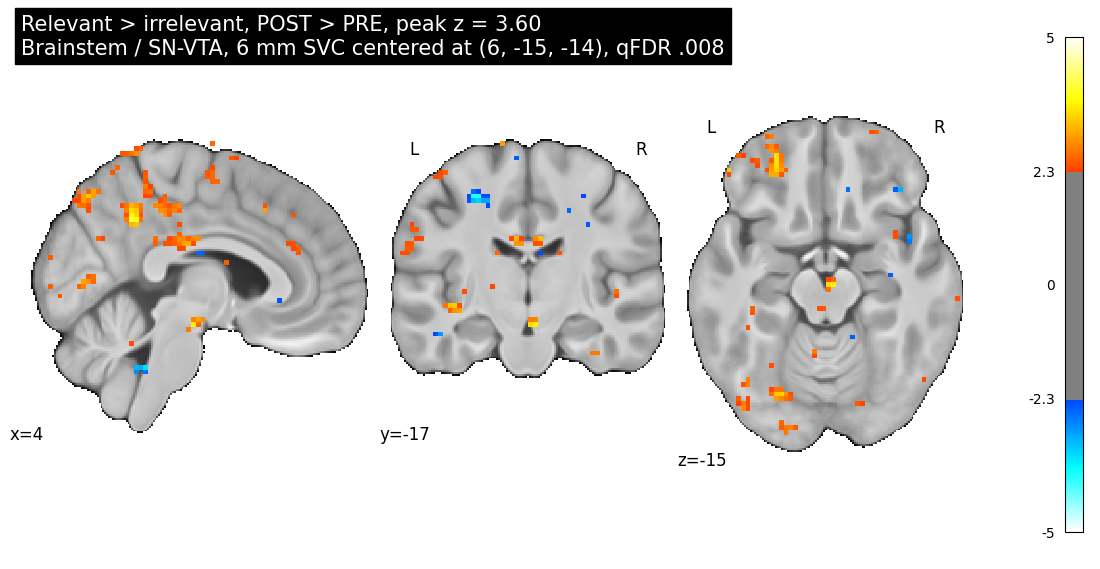

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_brainstem_sn_vta_wholebrain_no_cross.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_brainstem_sn_vta_wholebrain_no_cross.pdf


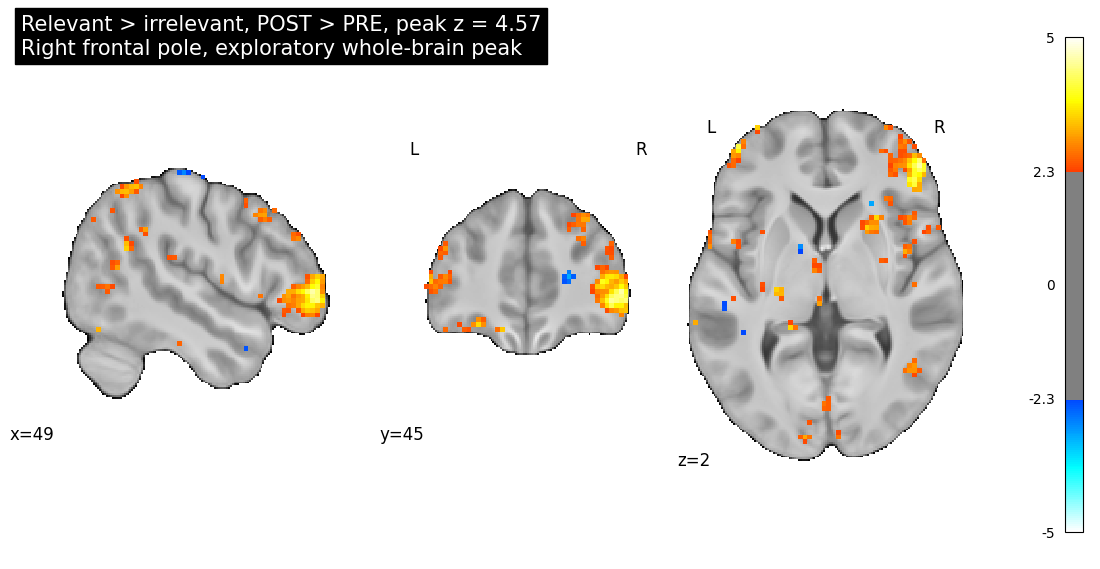

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_right_frontal_pole_wholebrain_no_cross.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_right_frontal_pole_wholebrain_no_cross.pdf


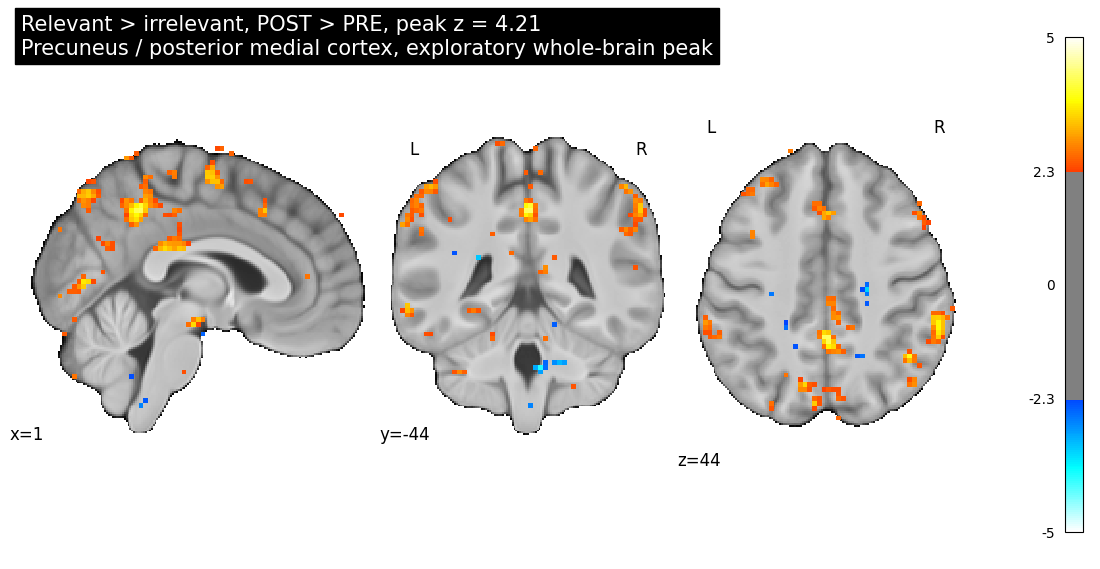

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_precuneus_posterior_medial_cortex_wholebrain_no_cross.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_precuneus_posterior_medial_cortex_wholebrain_no_cross.pdf


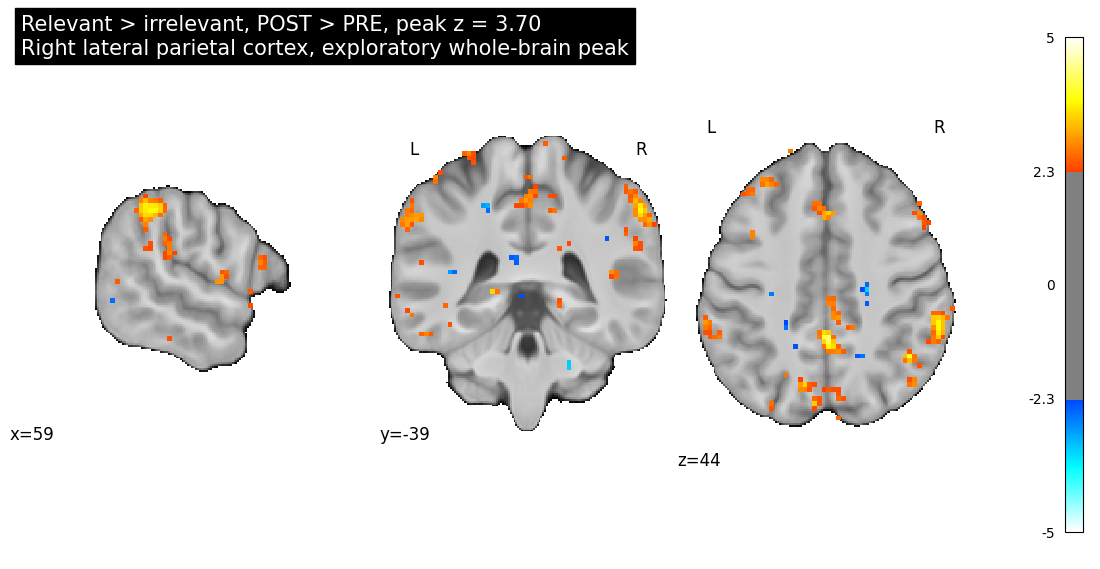

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_right_lateral_parietal_cortex_wholebrain_no_cross.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_right_lateral_parietal_cortex_wholebrain_no_cross.pdf

Final relevance figure table:


,Contrast,Region,Atlas label,Peak,Peak z,Figure type,SVC center,qFDR SVC,Literature support,PNG,PDF
0,"Relevant > irrelevant, POST > PRE",Brainstem / SN-VTA,—,"(4, -17, -16)",3.60,paper-sourced SVC,"(6, -15, -14)",.008,Yi et al. (2025),/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...
1,"Relevant > irrelevant, POST > PRE",Right frontal pole,—,"(49, 46, 2)",4.57,exploratory whole-brain peak,—,—,goal-directed control / rostrolateral PFC literature,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...
2,"Relevant > irrelevant, POST > PRE",Precuneus / posterior medial cortex,—,"(2, -44, 44)",4.21,exploratory whole-brain peak,—,—,Foudil et al. (2024),/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...
3,"Relevant > irrelevant, POST > PRE",Right lateral parietal cortex,—,"(59, -40, 44)",3.70,exploratory whole-brain peak,—,—,Favila et al. (2018),/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_po...


Saved figure table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/final_relevant_gt_irrelevant_post_gt_pre_selected_figures/pre_post_relevance_old_new_viewing_glm_rel_gt_irrel_post_gt_pre_final_selected_figure_index.csv


In [18]:
# ============================================================
# Relevant > Irrelevant, POST > PRE
# Final first-pass figures for presentation
#
# Figures:
# 1. Brainstem / SN-VTA
#    - literature-defined SVC center from Yi et al. (2025)
#    - qFDR reported in title
#
# 2. Precuneus / posterior medial cortex
#    - exploratory whole-brain peak
#    - no SVC yet
#
# 3. Right posterior supramarginal / IPL
#    - exploratory whole-brain peak
#    - no SVC yet
#    - chosen as lateral parietal result most consistent with goal-relevance literature
#
# Style:
# - whole-brain map
# - z > 2.33 display threshold
# - no black cross
# - same title convention as Old/New figures
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from nilearn import plotting
from nilearn.image import load_img

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

PRIMARY_CONTRAST = "rel_gt_irrel_post_gt_pre"
PRIMARY_LABEL = "Relevant > irrelevant, POST > PRE"

DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

final_rel_fig_dir = (
    dirs["figures"]
    / "final_relevant_gt_irrelevant_post_gt_pre_selected_figures"
)

final_rel_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", final_rel_fig_dir)

# ------------------------------------------------------------
# Load z-map
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found."

z_map_path = Path(
    second_level_table.set_index("contrast").loc[PRIMARY_CONTRAST, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using z-map:")
print(z_map_path)

# Background image
BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_coord(coord):
    return f"({coord[0]:.0f}, {coord[1]:.0f}, {coord[2]:.0f})"

def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)

    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)

def save_relevance_wholebrain_figure(
    z_img,
    cut_coords,
    title_text,
    out_stem,
    bg_img=None,
    threshold=2.33,
    vmax=5.0,
):
    png_path = final_rel_fig_dir / f"{out_stem}.png"
    pdf_path = final_rel_fig_dir / f"{out_stem}.pdf"

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    display = plotting.plot_stat_map(
        z_img,
        bg_img=bg_img,
        threshold=threshold,
        vmax=vmax,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=cut_coords,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved:")
    print(png_path)
    print(pdf_path)

    return png_path, pdf_path

# ------------------------------------------------------------
# Final selected figures
# ------------------------------------------------------------

FINAL_RELEVANCE_FIGURES = [
    {
        "result_name": "brainstem_sn_vta",
        "region_label": "Brainstem / SN-VTA",
        "peak_coord": (4.0, -17.0, -15.5),
        "svc_center": (6.0, -15.0, -14.0),
        "qfdr_label": ".008",
        "mode": "svc",
        "source": "Yi et al. (2025)",
    },
    {
        "result_name": "right_frontal_pole",
        "region_label": "Right frontal pole",
        "peak_coord": (49.0, 45.5, 2.0),
        "svc_center": None,
        "qfdr_label": None,
        "mode": "exploratory",
        "source": "goal-directed control / rostrolateral PFC literature",
    },
    {
        "result_name": "precuneus_posterior_medial_cortex",
        "region_label": "Precuneus / posterior medial cortex",
        "peak_coord": (1.5, -44.5, 44.5),
        "svc_center": None,
        "qfdr_label": None,
        "mode": "exploratory",
        "source": "Foudil et al. (2024)",
    },
    {
        "result_name": "right_lateral_parietal_cortex",
        "region_label": "Right lateral parietal cortex",
        "peak_coord": (59.0, -39.5, 44.5),
        "svc_center": None,
        "qfdr_label": None,
        "mode": "exploratory",
        "source": "Favila et al. (2018)",
    },
]

figure_rows = []

for spec in FINAL_RELEVANCE_FIGURES:

    peak_coord = spec["peak_coord"]
    peak_z, peak_voxel = z_at_mni_coord(z_img, peak_coord)

    if spec["mode"] == "svc":
        title_text = (
            f"{PRIMARY_LABEL}, peak z = {peak_z:.2f}\n"
            f"{spec['region_label']}, 6 mm SVC centered at "
            f"{fmt_coord(spec['svc_center'])}, qFDR {spec['qfdr_label']}"
        )
    else:
        title_text = (
            f"{PRIMARY_LABEL}, peak z = {peak_z:.2f}\n"
            f"{spec['region_label']}, exploratory whole-brain peak"
        )

    out_stem = (
        f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_"
        f"{spec['result_name']}_wholebrain_no_cross"
    )

    png_path, pdf_path = save_relevance_wholebrain_figure(
        z_img=z_img,
        cut_coords=peak_coord,
        title_text=title_text,
        out_stem=out_stem,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
    )

    figure_rows.append({
        "Contrast": PRIMARY_LABEL,
        "Region": spec["region_label"],
        "Atlas label": spec.get("atlas_label", "—"),
        "Peak": fmt_coord(peak_coord),
        "Peak z": f"{peak_z:.2f}",
        "Figure type": (
            "paper-sourced SVC" if spec["mode"] == "svc"
            else "exploratory whole-brain peak"
        ),
        "SVC center": (
            fmt_coord(spec["svc_center"]) if spec["svc_center"] is not None
            else "—"
        ),
        "qFDR SVC": spec["qfdr_label"] if spec["qfdr_label"] is not None else "—",
        "Literature support": spec["source"],
        "PNG": str(png_path),
        "PDF": str(pdf_path),
    })

# ------------------------------------------------------------
# Save figure index / report table
# ------------------------------------------------------------

relevance_final_figure_table = pd.DataFrame(figure_rows)

figure_table_csv = (
    final_rel_fig_dir
    / f"{ANALYSIS_NAME}_{PRIMARY_CONTRAST}_final_selected_figure_index.csv"
)

relevance_final_figure_table.to_csv(figure_table_csv, index=False)

print("\nFinal relevance figure table:")
display(relevance_final_figure_table)

print("Saved figure table:")
print(figure_table_csv)